In [16]:
import pandas as pd

df = pd.read_csv("/content/hist_india_vix_-19-04-2025-to-19-04-2026.csv")
print(df.head())

         Date     Open     High      Low   Close   Prev. Close   Change   \
0  21-APR-2025  15.4675  16.3325  14.2175   15.52       15.4675     0.05   
1  22-APR-2025  15.5150  16.0075  14.5400   15.23       15.5150    -0.29   
2  23-APR-2025  15.2300  16.5175  12.8425   15.96       15.2300     0.73   
3  24-APR-2025  15.9600  16.7625  15.5525   16.25       15.9600     0.29   
4  25-APR-2025  16.2500  17.5750  15.9150   17.16       16.2500     0.91   

   % Change   
0       0.34  
1      -1.84  
2       4.79  
3       1.82  
4       5.60  


In [21]:
print(df.columns)


Index(['Date', 'Open', 'High', 'Low', 'Close', 'Prev. Close', 'Change',
       '% Change'],
      dtype='object')


In [22]:
df.columns = df.columns.str.strip()

In [25]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

/tmp/ipykernel_8187/1929082916.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [26]:
df = df.fillna(method='ffill')

/tmp/ipykernel_8187/569672361.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [27]:
df = df.sort_index()

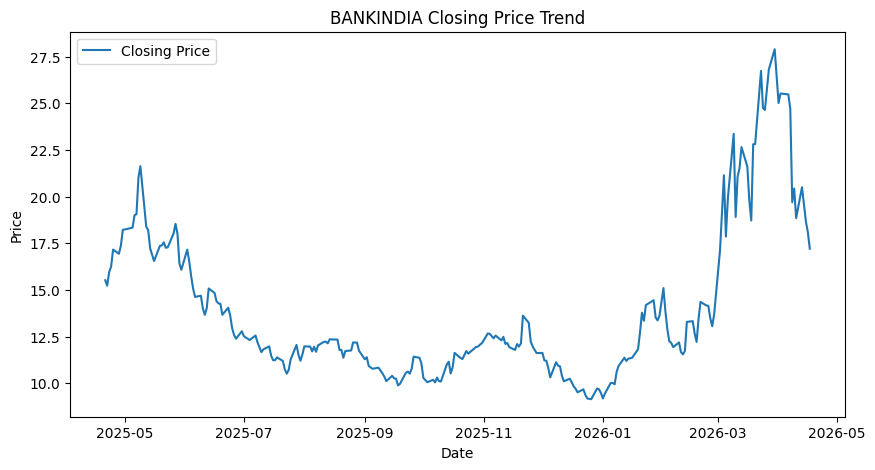

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Close'], label='Closing Price')
plt.title('BANKINDIA Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [31]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Close'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -3.3242892834802404
p-value: 0.013827044745774753


In [32]:

df['Close_diff'] = df['Close'].diff().dropna()

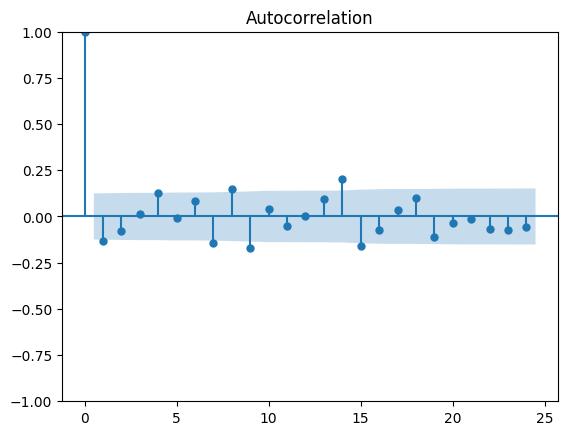

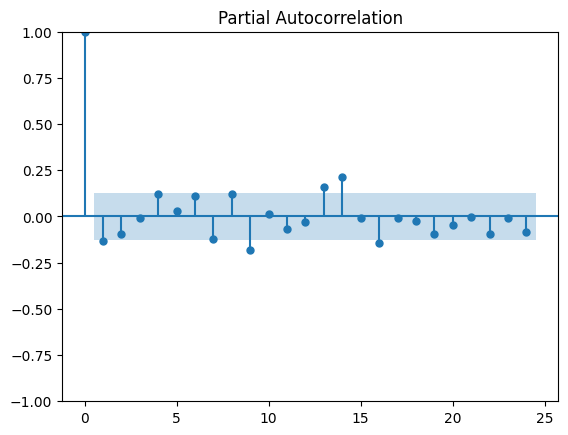

In [33]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['Close_diff'].dropna())
plot_pacf(df['Close_diff'].dropna())
plt.show()

In [35]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['Close'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  247
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -340.585
Date:                Sun, 19 Apr 2026   AIC                            687.170
Time:                        09:41:07   BIC                            697.686
Sample:                             0   HQIC                           691.404
                                - 247                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1746      0.260      0.673      0.501      -0.334       0.683
ma.L1         -0.3257      0.244     -1.337      0.181      -0.803       0.152
sigma2         0.9333      0.037     25.387      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


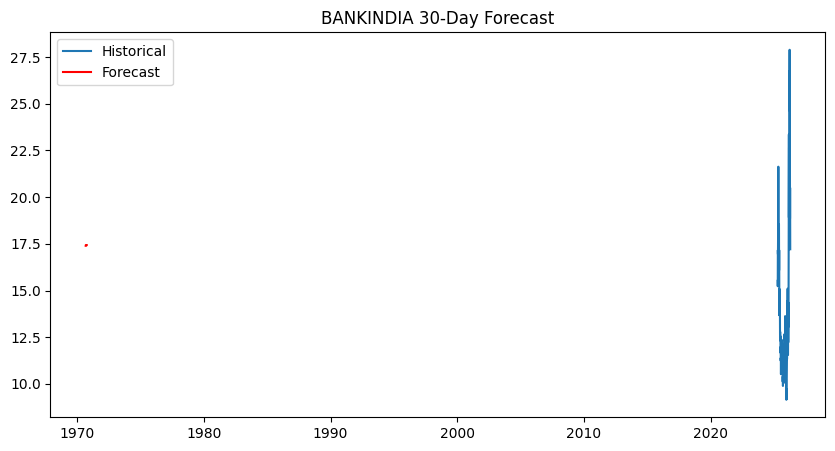

In [38]:
forecast = model_fit.forecast(steps=30)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Close'], label='Historical')
plt.plot(forecast, label='Forecast', color='red')
plt.title('BANKINDIA 30-Day Forecast')
plt.legend()
plt.show()